In [ ]:
import os
import numpy as np

# Define the directory where the processed L1 norm files are stored
base_dir = "/home/tersenov/CosmoGridV1/stage3_forecast/grid/"

# Collect all the expected L1 norm filenames
l1_norm_files = []
missing_files = []

In [ ]:
# Iterate over all cosmology and permutation directories
for cosmo_dir in sorted(os.listdir(base_dir)):
    cosmo_path = os.path.join(base_dir, cosmo_dir)
    
    if not os.path.isdir(cosmo_path):  # Skip non-directory files
        continue

    for perm_dir in sorted(os.listdir(cosmo_path)):
        perm_path = os.path.join(cosmo_path, perm_dir)
        
        if not os.path.isdir(perm_path):  # Skip non-directory files
            continue

        # Define the expected L1 norm file path
        file_path = os.path.join(perm_path, "projected_probes_maps_baryonified512_l1_norms_bin2_noisy_s026.npy")

        if os.path.exists(file_path):
            l1_norm_files.append(file_path)
        else:
            missing_files.append(file_path)  # Keep track of missing files

# Load all available L1 norm files
all_l1_norms = []
for file in l1_norm_files:
    data = np.load(file)  # Shape: (scales, bins)
    
    if len(data.shape) != 2:
        print(f"Skipping {file} due to unexpected shape {data.shape}")
        continue

    all_l1_norms.append(data)

# Convert list to numpy array with shape (realisations, scales, bins)
if all_l1_norms:
    all_l1_norms = np.stack(all_l1_norms, axis=0)  # Shape: (realisations, scales, bins)
    print(f"Loaded {len(l1_norm_files)} files successfully with shape {all_l1_norms.shape}.")
else:
    print("No valid L1 norm files found!")
    all_l1_norms = None

# Print missing files
if missing_files:
    print(f"Missing {len(missing_files)} files:")
    for missing in missing_files:
        print(missing)


In [7]:
# Save the combined array if needed
np.save(os.path.join(base_dir, "all_l1_norms_bin1_baryonified_noisy_s026.npy"), all_l1_norms)
print(f"Saved concatenated L1 norms to: {base_dir}all_l1_norms_bin1_baryonified_noisy_s026.npy")

Saved concatenated L1 norms to: /home/tersenov/CosmoGridV1/stage3_forecast/grid/all_l1_norms_bin1_baryonified_noisy_s026.npy


In [8]:
all_l1_norms.shape

(16966, 5, 40)

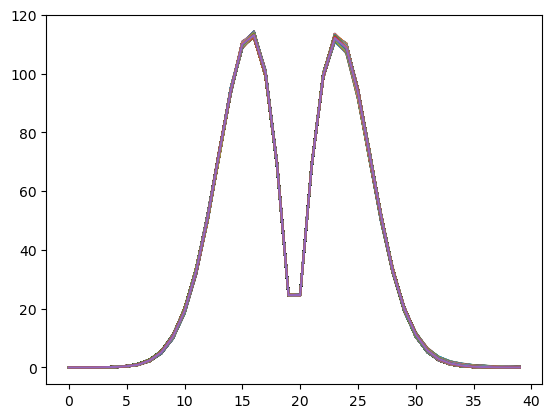

In [9]:
import matplotlib.pyplot as plt
for i in range(16965):
    plt.plot(all_l1_norms[i][0])

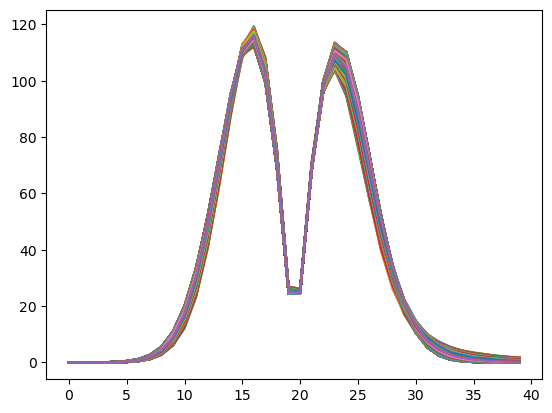

In [10]:
for i in range(16965):
    plt.plot(all_l1_norms[i][1])

In [6]:
# read h5 file
import h5py
with h5py.File('/home/tersenov/CosmoGridV1/CosmoGridV1_metainfo.h5') as f:
    print(f.keys())
    params = f['parameters']
    print(params.keys())
    params_grid = f['parameters/grid']
    print(params_grid)
    

<KeysViewHDF5 ['parameters', 'shell_info', 'simulations']>
<KeysViewHDF5 ['all', 'benchmark', 'fiducial', 'grid']>
<HDF5 dataset "grid": shape (2500,), type "|V528">


In [7]:
import numpy as np
filename = "/home/tersenov/CosmoGridV1/CosmoGridV1_metainfo.h5"
f = h5py.File(filename, "r")
dataset_grid = f["parameters"]["grid"]

cosmo_parameters = np.array(
    [
        dataset_grid["Om"],
        dataset_grid["s8"],
        dataset_grid["w0"],
        dataset_grid["H0"],
        dataset_grid["ns"],
        dataset_grid["Ob"],
    ]
).T

In [8]:
cosmo_parameters[2345]

array([ 3.83836365e-01,  5.04389191e-01, -1.11829166e+00,  6.52431717e+01,
        9.76232452e-01,  4.23695755e-02])

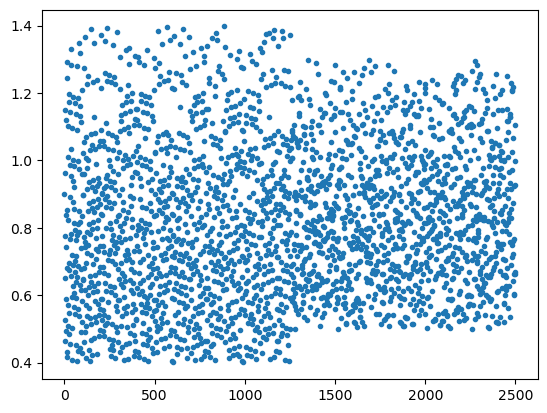

In [10]:
import matplotlib.pyplot as plt
plt.scatter(np.arange(2500),cosmo_parameters[:,1], marker='.')

In [11]:
cosmo_parameters[0]

array([ 3.0000e-01,  9.0000e-01, -1.1665e+00,  7.3000e+01,  9.7000e-01,
        4.5000e-02])

In [9]:
import os
import h5py
import numpy as np

# Define paths
base_dir = "/home/tersenov/CosmoGridV1/stage3_forecast/grid/"
meta_file = "/home/tersenov/CosmoGridV1/CosmoGridV1_metainfo.h5"

# Load cosmological parameters
with h5py.File(meta_file, "r") as f:
    dataset_grid = f["parameters"]["grid"]
    cosmo_parameters = np.array([
        dataset_grid["Om"],
        dataset_grid["s8"],
        dataset_grid["w0"],
        dataset_grid["H0"],
        dataset_grid["ns"],
        dataset_grid["Ob"],
    ]).T  # Shape: (num_realizations, 6)
    paths = [p.decode("utf-8") for p in dataset_grid["path_par"]]


In [10]:
# Initialize lists
l1_norm_files = []
missing_files = []
cosmo_params_list = []

# Iterate through cosmology directories
for cosmo_idx, cosmo_dir in enumerate(sorted(os.listdir(base_dir))):
    cosmo_path = os.path.join(base_dir, cosmo_dir)

    if not os.path.isdir(cosmo_path):  # Skip non-directories
        continue

    for perm_dir in sorted(os.listdir(cosmo_path)):
        perm_path = os.path.join(cosmo_path, perm_dir)

        if not os.path.isdir(perm_path):  # Skip non-directories
            continue

        # Find matching cosmology parameters based on the directory structure
        matching_idx = next((i for i, p in enumerate(paths) if cosmo_dir in p), None)
        if matching_idx is None:
            print(f"Warning: No matching parameters found for {cosmo_dir}")
            continue

        # Define L1 norm file path
        file_path = os.path.join(perm_path, "projected_probes_maps_baryonified512_l1_norms_bin1.npy")

        if os.path.exists(file_path):
            l1_norm_files.append(file_path)
            cosmo_params_list.append(cosmo_parameters[matching_idx])  # Append matching parameters
        else:
            missing_files.append(file_path)

In [11]:
# Load all available L1 norm files
all_l1_norms = []
for file in l1_norm_files:
    data = np.load(file)  # Expected shape: (scales, bins)

    if len(data.shape) != 2:
        print(f"Skipping {file} due to unexpected shape {data.shape}")
        continue

    all_l1_norms.append(data)

# Convert to numpy arrays
if all_l1_norms:
    all_l1_norms = np.stack(all_l1_norms, axis=0)  # Shape: (realisations, scales, bins)
    cosmo_params_array = np.array(cosmo_params_list)  # Shape: (realisations, 6)
    print(f"Loaded {len(l1_norm_files)} L1 norm files with shape {all_l1_norms.shape}.")
else:
    print("No valid L1 norm files found!")
    all_l1_norms = None
    cosmo_params_array = None

# Print missing files
if missing_files:
    print(f"Missing {len(missing_files)} files:")
    for missing in missing_files:
        print(missing)

# Save arrays
if all_l1_norms is not None and cosmo_params_array is not None:
    # np.save(os.path.join(base_dir, "all_l1_norms.npy"), all_l1_norms)
    np.save(os.path.join(base_dir, "cosmo_params_baryonified.npy"), cosmo_params_array)
    print(f"Saved L1 norms and cosmological parameters to {base_dir}")


Loaded 16966 L1 norm files with shape (16966, 5, 40).
Missing 247 files:
/home/tersenov/CosmoGridV1/stage3_forecast/grid/cosmo_193238/perm_0005/projected_probes_maps_baryonified512_l1_norms_bin1.npy
/home/tersenov/CosmoGridV1/stage3_forecast/grid/cosmo_193238/perm_0006/projected_probes_maps_baryonified512_l1_norms_bin1.npy
/home/tersenov/CosmoGridV1/stage3_forecast/grid/cosmo_193250/perm_0000/projected_probes_maps_baryonified512_l1_norms_bin1.npy
/home/tersenov/CosmoGridV1/stage3_forecast/grid/cosmo_193250/perm_0001/projected_probes_maps_baryonified512_l1_norms_bin1.npy
/home/tersenov/CosmoGridV1/stage3_forecast/grid/cosmo_193250/perm_0002/projected_probes_maps_baryonified512_l1_norms_bin1.npy
/home/tersenov/CosmoGridV1/stage3_forecast/grid/cosmo_193250/perm_0003/projected_probes_maps_baryonified512_l1_norms_bin1.npy
/home/tersenov/CosmoGridV1/stage3_forecast/grid/cosmo_193250/perm_0004/projected_probes_maps_baryonified512_l1_norms_bin1.npy
/home/tersenov/CosmoGridV1/stage3_forecast/gr

In [12]:
all_l1_norms.shape, cosmo_params_array.shape

((16966, 5, 40), (16966, 6))

In [13]:
cosmo_params_array[:10]

array([[ 3.00000e-01,  9.00000e-01, -1.16650e+00,  7.30000e+01,
         9.70000e-01,  4.50000e-02],
       [ 3.00000e-01,  9.00000e-01, -1.16650e+00,  7.30000e+01,
         9.70000e-01,  4.50000e-02],
       [ 3.00000e-01,  9.00000e-01, -1.16650e+00,  7.30000e+01,
         9.70000e-01,  4.50000e-02],
       [ 3.00000e-01,  9.00000e-01, -1.16650e+00,  7.30000e+01,
         9.70000e-01,  4.50000e-02],
       [ 3.00000e-01,  9.00000e-01, -1.16650e+00,  7.30000e+01,
         9.70000e-01,  4.50000e-02],
       [ 3.00000e-01,  9.00000e-01, -1.16650e+00,  7.30000e+01,
         9.70000e-01,  4.50000e-02],
       [ 3.00000e-01,  9.00000e-01, -1.16650e+00,  7.30000e+01,
         9.70000e-01,  4.50000e-02],
       [ 4.00000e-01,  6.50000e-01, -1.58325e+00,  6.85000e+01,
         1.02000e+00,  5.25000e-02],
       [ 4.00000e-01,  6.50000e-01, -1.58325e+00,  6.85000e+01,
         1.02000e+00,  5.25000e-02],
       [ 4.00000e-01,  6.50000e-01, -1.58325e+00,  6.85000e+01,
         1.02000e+00,  5.25

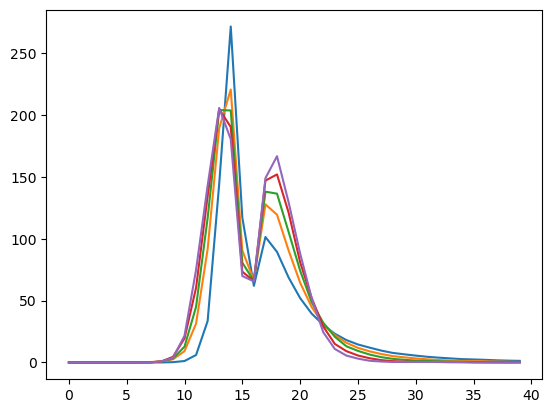

In [14]:
import matplotlib.pyplot as plt
for j in range(5):
    plt.plot(all_l1_norms[10840][j])

## Fiducial

In [11]:
import os
import numpy as np

# Define the directory where the processed L1 norm files are stored
base_dir = "/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/"

# Collect all the expected L1 norm filenames
l1_norm_files = []
missing_files = []


In [12]:
# Iterate over all cosmology and permutation directories
for perm_dir in sorted(os.listdir(base_dir)):
    perm_path = os.path.join(base_dir, perm_dir)
    
    if not os.path.isdir(perm_path):  # Skip non-directory files
        continue

    # Define the expected L1 norm file path
    file_path = os.path.join(perm_path, "projected_probes_maps_baryonified512_l1_norms_bin1_noisy_s026.npy")

    if os.path.exists(file_path):
        l1_norm_files.append(file_path)
    else:
        missing_files.append(file_path)  # Keep track of missing files

# Load all available L1 norm files
all_l1_norms = []
for file in l1_norm_files:
    data = np.load(file)  # Shape: (scales, bins)
    
    if len(data.shape) != 2:
        print(f"Skipping {file} due to unexpected shape {data.shape}")
        continue

    all_l1_norms.append(data)

# Convert list to numpy array with shape (realisations, scales, bins)
if all_l1_norms:
    all_l1_norms = np.stack(all_l1_norms, axis=0)  # Shape: (realisations, scales, bins)
    print(f"Loaded {len(l1_norm_files)} files successfully with shape {all_l1_norms.shape}.")
else:
    print("No valid L1 norm files found!")
    all_l1_norms = None

# Print missing files
if missing_files:
    print(f"Missing {len(missing_files)} files:")
    for missing in missing_files:
        print(missing)

# Save the combined array if needed
np.save(os.path.join(base_dir, "all_l1_norms_baryonified_fid_bin1_noisy_s026.npy"), all_l1_norms)
print(f"Saved concatenated L1 norms to: {base_dir}/all_l1_norms_baryonified_fid_bin1_noisy_s026.npy")

Loaded 200 files successfully with shape (200, 5, 40).
Saved concatenated L1 norms to: /home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial//all_l1_norms_baryonified_fid_bin1_noisy_s026.npy


In [10]:
all_l1_norms_bin1 = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial//all_l1_norms_fid_bin1.npy', allow_pickle=True)
# all_l1_norms_bin2 = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial//all_l1_norms_fid_bin2.npy', allow_pickle=True)
# all_l1_norms_bin3 = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial//all_l1_norms_fid_bin3.npy', allow_pickle=True)
# all_l1_norms_bin4 = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial//all_l1_norms_fid_bin4.npy', allow_pickle=True)
all_l1_norms_bar_bin1 = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial//all_l1_norms_baryonified_fid_bin1.npy', allow_pickle=True)
all_l1_norms_bar_bin1_noisy = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial//all_l1_norms_baryonified_fid_bin1_noisy.npy', allow_pickle=True)
all_l1_norms_nobar_bin1_noisy = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial//all_l1_norms_nobaryons_fid_bin1_noisy.npy', allow_pickle=True)


In [11]:
all_l1_norms_bin1.shape, all_l1_norms_bar_bin1.shape, all_l1_norms_bar_bin1_noisy.shape, all_l1_norms_nobar_bin1_noisy.shape

((200, 5, 40), (200, 5, 40), (200, 5, 40), (200, 5, 40))

In [12]:
bins1 = np.linspace(-0.004, 0.006, 40)
bins2 = np.linspace(-0.003, 0.003, 40)

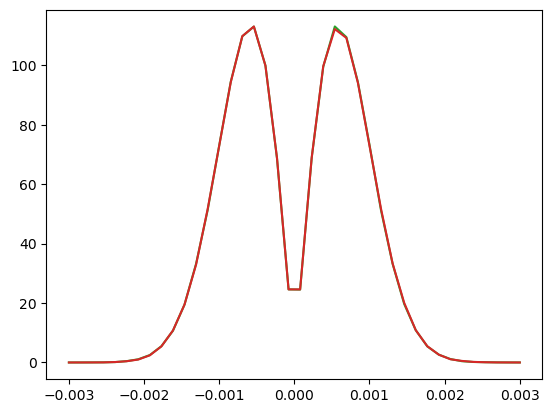

In [16]:
import matplotlib.pyplot as plt
# for i in range(1):
    # plt.plot(bins1, all_l1_norms_bin1[0,i], color='C0')
# for i in range(1):
#     plt.plot(all_l1_norms_bin2[0,i], color='C1')
# for i in range(1):
#     plt.plot(all_l1_norms_bin3[0,i], color='C2')
# for i in range(1):
#     plt.plot(all_l1_norms_bin4[0,i], color='C3')
# for i in range(1):
    # plt.plot(bins1, all_l1_norms_bar_bin1[0,i], color='C1')
for i in range(1):
    plt.plot(bins2, all_l1_norms_bar_bin1_noisy[0,i], color='C2')
for i in range(1):
    plt.plot(bins2, all_l1_norms_nobar_bin1_noisy[0,i], color='C3')